# Least Squares (Intercept Only)


On dot product and cosine: https://www.youtube.com/watch?v=afHTz7jrmGo

Imagine that we have conducted an experiment on the effectiveness of a diet on weight loss. We have randomly chosen 100 people and have put them on a diet for some period. We also follow another 100 persons who are not on a diet. We have measured the weight of each person before and after the experiment. The code below simulates such an experiment.

Our ultimate goal will be to estimate the average weight loss due to the diet but before doing that we will focus on a simpler task: we want to estimate the (unknown) population average weight by taking a sample. We also want to estimate the variance of the weight distribution.

## The Geometry of Least Squares

[Desmos](https://www.desmos.com/geometry/k2yatxmvnl)

## Estimating the variance

Until now we have successfully estimated the population mean using the sample mean. However, we have not yet estimated the population variance $\sigma^2$.

$$
\sigma^2 = E[(X - \mu)^2]
$$

and it is the average squared distance from the (population/distribution) mean. We managed to show that the sample mean is an unbiased estimator (function of the data) for the population mean. Now we would like to look for an unbiased estimator of the population variance, meaning that some function of the data should have the property:

$$
E[\hat{\sigma}^2] = \sigma^2
$$


In [1]:
if (!requireNamespace("tidyverse", quietly = TRUE)) {
  install.packages("tidyverse")
}

suppressMessages(library(tidyverse))

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────

In [2]:
R <- 3000
n <- 10
mu <- 80
sigma <- 10

samples <- tibble(
  batch = rep(1:R, each = n),
  value = rnorm(R * n, mean = mu, sd = sigma)
)

samples


batch,value
<int>,<dbl>
1,69.10783
1,80.64296
1,73.39696
1,100.46456
1,91.47634
1,86.81157
1,85.29111
1,70.31183
1,66.64796


In [3]:
means <- samples %>%
  group_by(batch) %>%
  summarise(mean = mean(value))
means

batch,mean
<int>,<dbl>
1,80.65622
2,79.75294
3,77.62425
4,83.12828
5,85.17278
6,80.89055
7,81.69567
8,85.89572
9,78.81454


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


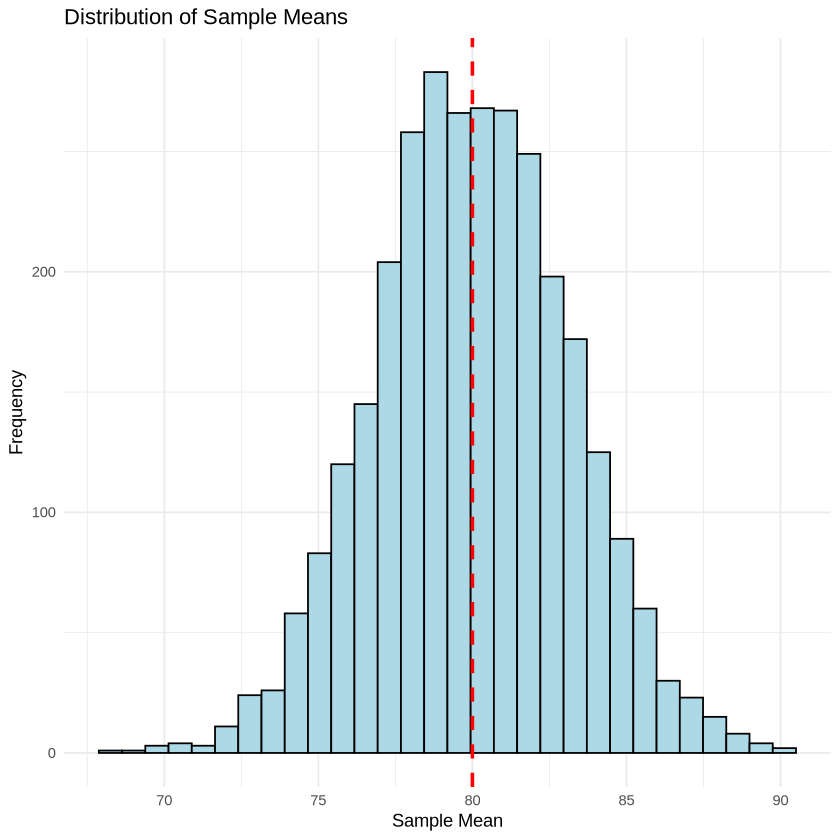

In [4]:
# Plot the distribution of the sample means

ggplot(means, aes(x = mean)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "black") +
  geom_vline(xintercept = mu, color = "red", linetype = "dashed", size = 1) +
  labs(title = "Distribution of Sample Means", x = "Sample Mean", y = "Frequency") +
  theme_minimal()

## Expected value and variance of the sample mean

Last time we derived the expected value and the variance of the sample mean. If we have $X_1, X_2, \ldots, X_n$ independent and identically distributed random variables with mean $\mu$ and variance $\sigma^2$, then the sample mean $\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i$ has expected value $E[\bar{X}] = \mu$ and variance $Var(\bar{X}) = \frac{\sigma^2}{n}$.

We can show these using only a few rules for expected value and variance. 

1. Rule 1 (X and Y are random variables)

$$
E(X + Y) = E(X) + E(Y)
$$

2. Rule 2 (a and b are constants)

$$
E(aX + b) = aE(X) + b
$$

The variance of a distribution is the expected value of the squared distance from the mean:

$$
Var(X) = E[(X - E(X))^2]
$$


3. Rule 3 (X and Y are independent)

$$
Var(X + Y) = Var(X) + Var(Y)
$$

4. Rule 4 (a and b are constants)

$$
Var(aX + b) = a^2 Var(X)
$$



The sample mean is defined as:

$$
\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i = \frac{1}{n} \left( X_1 + X_2 + \ldots + X_n \right)
$$

Taking the expectation of both sides and using the rules above, we get:

$$
E(\bar{X}) = E\left( \frac{1}{n} \sum_{i=1}^n X_i \right) = \frac{1}{n} \sum_{i=1}^n E[X_i] = \frac{1}{n} \cdot n \cdot \mu = \mu
$$

We say that the sample mean is an unbiased _estimator_ of the population mean.

To find the variance of the sample mean, we use the same rules:

$$
Var(\bar{X}) = Var\left( \frac{1}{n} \sum_{i=1}^n X_i \right) = \frac{1}{n^2} Var\left( \sum_{i=1}^n X_i \right) = \frac{1}{n^2} \sum_{i=1}^n Var(X_i) = \frac{1}{n^2} \cdot n \cdot \sigma^2 = \frac{\sigma^2}{n}
$$


In [5]:
sigmas <- samples %>%
  group_by(batch) %>%
  summarise(
    sd_sample = sd(value),
    sd_uncorrected = (n - 1) / n * sd(value)    
    )


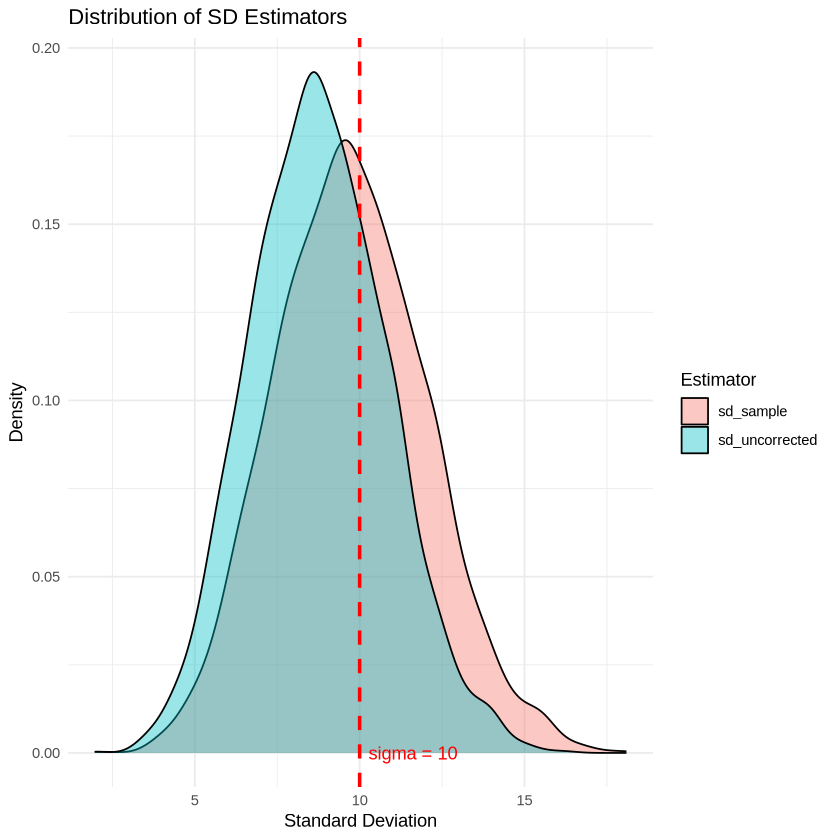

In [6]:
sigmas_long <- sigmas %>%
  pivot_longer(cols = c(sd_sample, sd_uncorrected),
               names_to = "estimator",
               values_to = "sd")

ggplot(sigmas_long, aes(x = sd, fill = estimator)) +
  geom_density(alpha = 0.4) +
  geom_vline(xintercept = sigma, color = "red", linetype = "dashed", linewidth = 1) +
  annotate("text", x = sigma, y = 0, label = paste("sigma =", sigma),
           hjust = -0.1, color = "red") +
  labs(title = "Distribution of SD Estimators",
       x = "Standard Deviation", y = "Density", fill = "Estimator") +
  theme_minimal()
